# EDA: LendingClub Default Prediction

Goal: find which features relate most to `default`, backed by statistics, before training a tree-based model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid')

TARGET = 'default'
df = pd.read_parquet('../data/interim/lendingclub_clean.parquet')
df['credit_hist_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

## 1. Overview and time split

In [2]:
print(f'Shape: {df.shape}')
print(f'Date range: {df.issue_d.min():%b %Y} to {df.issue_d.max():%b %Y}')
print(f'Default rate: {df[TARGET].mean():.2%}')

year = df['issue_d'].dt.year
display(df.groupby(year)[TARGET].agg(loans='size', default_rate='mean'))
display(df.pivot_table(index=year, columns='term', values=TARGET, aggfunc='mean').rename(columns=lambda t: f'{t}m default rate'))

Shape: (453809, 74)
Date range: Jun 2007 to Dec 2014
Default rate: 17.03%


,loans,default_rate
issue_d,,
2007,603,0.262
2008,2393,0.207
2009,5281,0.137
2010,12537,0.140
2011,21721,0.152
2012,53367,0.162
2013,134804,0.156
2014,223103,0.184


term,36m default rate,60m default rate
issue_d,,
2007,0.262,NaN
2008,0.207,NaN
2009,0.137,NaN
2010,0.109,0.224
2011,0.106,0.236
2012,0.136,0.277
2013,0.123,0.251
2014,0.137,0.311


In [3]:
# time-based split: all statistics below use the training part only
train = df[df['issue_d'] < '2014-01-01']
valid = df[df['issue_d'] >= '2014-01-01']
print(f'train: {len(train):,} loans, default rate {train[TARGET].mean():.2%}')
print(f'valid: {len(valid):,} loans, default rate {valid[TARGET].mean():.2%}')

train: 230,706 loans, default rate 15.65%
valid: 223,103 loans, default rate 18.45%


## 2. Missing values

In [4]:
miss = train.isna().mean().mul(100)
miss = miss[miss > 0].sort_values(ascending=False)
rows = {c: {'missing_pct': miss[c],
            'default_if_missing': train.loc[train[c].isna(), TARGET].mean(),
            'default_if_present': train.loc[train[c].notna(), TARGET].mean()} for c in miss.index}
display(pd.DataFrame(rows).T)

,missing_pct,default_if_missing,default_if_present
mths_since_last_record,90.844,0.155,0.175
mths_since_last_major_derog,85.907,0.155,0.164
mths_since_recent_bc_dlq,84.072,0.157,0.155
mths_since_recent_revol_delinq,76.402,0.157,0.156
mths_since_last_delinq,58.297,0.154,0.160
mo_sin_old_il_acct,33.119,0.159,0.155
num_tl_120dpd_2m,30.572,0.158,0.156
pct_tl_nvr_dlq,30.528,0.158,0.156
mths_since_recent_inq,30.516,0.143,0.162
avg_cur_bal,30.464,0.158,0.156


## 3. Categorical features: chi-square test and Cramér's V

In [5]:
cat_cols = ['term', 'home_ownership', 'verification_status', 'purpose', 'zip_code', 'addr_state', 'emp_length']

rows = []
for c in cat_cols:
    tab = pd.crosstab(train[c].astype(str), train[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(tab)
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    rows.append({'feature': c, 'categories': tab.shape[0], 'chi2': chi2, 'p_value': p, 'cramers_v': v})
cat_stats = pd.DataFrame(rows).set_index('feature').sort_values('cramers_v', ascending=False)
display(cat_stats.style.format({'chi2': '{:,.0f}', 'p_value': '{:.2e}', 'cramers_v': '{:.3f}'}))

,categories,chi2,p_value,cramers_v
feature,,,,
term,2,"5,047",0.00e+00,0.148
purpose,14,"1,052",1.07e-216,0.068
verification_status,3,845,3.69e-184,0.061
addr_state,50,393,2.95e-55,0.041
home_ownership,4,321,2.98e-69,0.037
emp_length,12,163,3.33e-29,0.027
zip_code,10,107,5.66e-19,0.022


### Categorical Feature Association with the Target

The chi-square test of independence and Cramér's V were used to evaluate the relationship between categorical features and the target variable.

* **`term` has the strongest association with the target** among the evaluated categorical features, with a Cramér's V of 0.148. However, this still indicates a relatively weak association.
* **`purpose` and `verification_status`** show weaker associations, with Cramér's V values of 0.068 and 0.061, respectively.
* **`addr_state`, `home_ownership`, and `zip_code`** have very weak associations with the target.
* **`emp_length` has the weakest association** among the evaluated features, with a Cramér's V of 0.010.

All features have p-values below 0.05, indicating statistically significant evidence against the null hypothesis of independence. However, statistical significance does not necessarily imply a strong relationship, particularly in a large dataset where even small associations can be statistically significant.

**Conclusion:** Although all evaluated categorical features show statistically significant relationships with the target, their Cramér's V values indicate that these relationships are weak in magnitude. `term` has the strongest association among the evaluated features, while `emp_length` has the weakest. These findings will inform further feature analysis, but feature selection decisions should also consider domain relevance, data quality, leakage risk, and predictive performance.


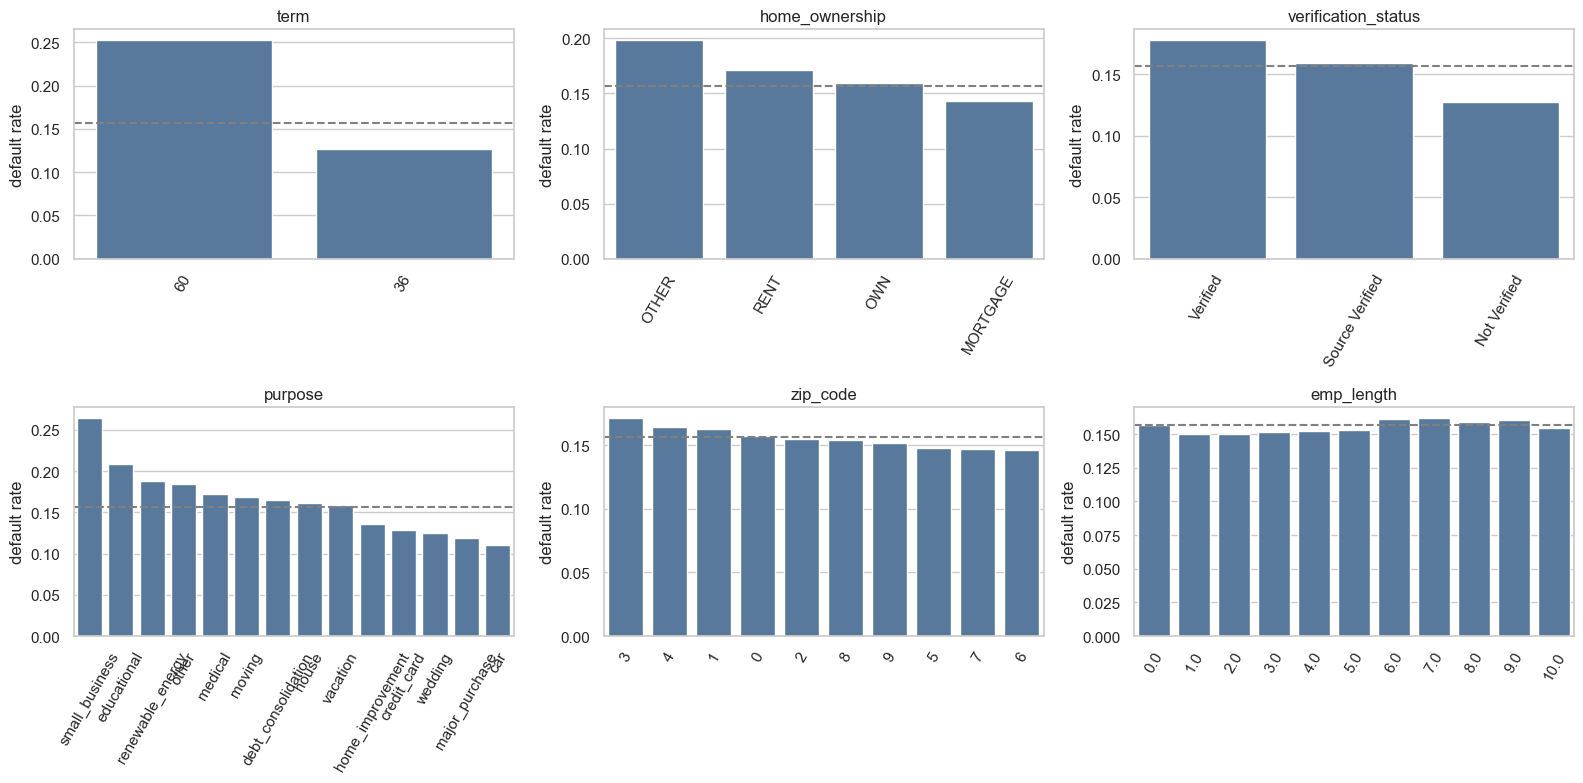

In [6]:
plot_cols = [c for c in cat_cols if c != 'addr_state']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, plot_cols):
    g = train.groupby(c, observed=True)[TARGET].mean().sort_values(ascending=False) if c != 'emp_length' else train.groupby(c)[TARGET].mean()
    sns.barplot(x=g.index.astype(str), y=g.values, color='#4C78A8', ax=ax)
    ax.axhline(train[TARGET].mean(), ls='--', color='grey')
    ax.set(title=c, xlabel='', ylabel='default rate')
    ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

**Observation:** The plots support the statistical findings: `term` shows the largest difference in default rates, while `emp_length` has nearly uniform rates across categories. Other features show relatively small to moderate differences, indicating generally weak associations with the target.


## 4. Numerical features: Mann-Whitney U test and AUC

In [7]:
num_cols = [c for c in train.select_dtypes(include=np.number).columns if c not in (TARGET, 'term')]

rows = []
for c in num_cols:
    x1 = train.loc[train[TARGET] == 1, c].dropna()
    x0 = train.loc[train[TARGET] == 0, c].dropna()
    u, p = stats.mannwhitneyu(x1, x0, method='asymptotic')
    rows.append({'feature': c, 'coverage_pct': train[c].notna().mean() * 100,
                 'median_default': x1.median(), 'median_non_default': x0.median(),
                 'auc': u / (len(x1) * len(x0)), 'p_value': p})

num_stats = pd.DataFrame(rows).set_index('feature')
num_stats['auc_strength'] = (num_stats['auc'] - 0.5).abs() + 0.5
num_stats = num_stats.sort_values('auc_strength', ascending=False)
display(num_stats.head(25).style.format({'p_value': '{:.2e}'}))

,coverage_pct,median_default,median_non_default,auc,p_value,auc_strength
feature,,,,,,
fico_range_low,100.000000,685.000000,695.000000,0.408870,0.00e+00,0.591130
fico_range_high,100.000000,689.000000,699.000000,0.408870,0.00e+00,0.591130
bc_open_to_buy,77.651210,2588.000000,3727.000000,0.435012,1.05e-263,0.564988
acc_open_past_24mths,78.314391,4.000000,3.000000,0.564692,4.48e-268,0.564692
num_tl_op_past_12m,69.538720,2.000000,1.000000,0.559035,7.19e-204,0.559035
dti,100.000000,17.690000,15.840000,0.558311,3.66e-272,0.558311
annual_inc,99.998266,56500.000000,62200.000000,0.444775,2.12e-244,0.555225
revol_util,99.906808,63.300000,58.100000,0.554861,6.98e-241,0.554861
mo_sin_rcnt_tl,69.538720,5.000000,6.000000,0.445620,1.05e-165,0.554380


**Conclusion:** Median values are generally relatively close between defaulted and non-defaulted loans, although some features show noticeable differences. Very low p-values indicate statistically significant distributional differences, but do not necessarily imply strong associations. AUC values near 0.5 indicate weak separation, while values below or above 0.5 indicate the direction of separation. `auc_strength` measures separation regardless of direction. Overall, the analyzed numerical features show varying degrees of univariate separation and should be evaluated further alongside domain knowledge, leakage risk, and model performance.


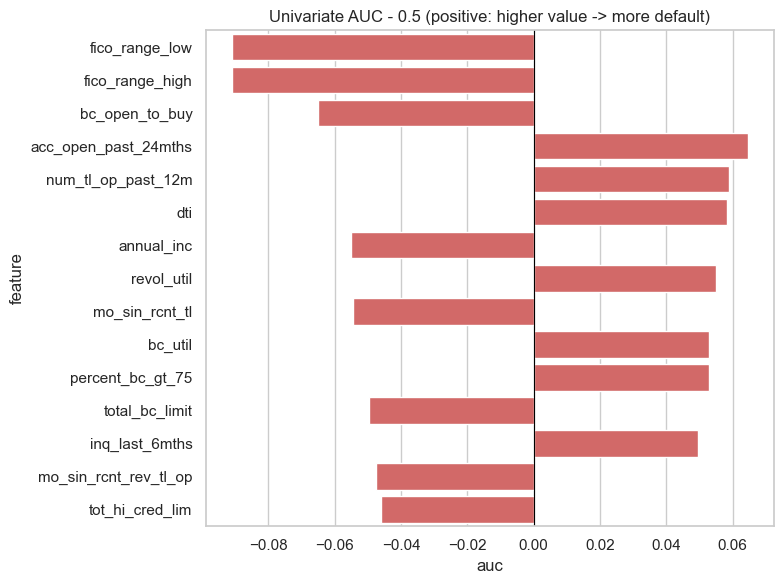

In [8]:
top = num_stats.head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=top['auc'] - 0.5, y=top.index, color='#E45756')
plt.axvline(0, color='black', lw=0.8)
plt.title('Univariate AUC - 0.5 (positive: higher value -> more default)')
plt.tight_layout()
plt.show()

**Conclusion:** for your documentation: Higher DTI, revolving utilization, and recent credit inquiries tend to be associated with defaults, whereas lower FICO scores, income, and available credit tend to be associated with defaults. These are univariate associations, not evidence of causation, and the graph does not establish each feature's independent contribution to a combined model.

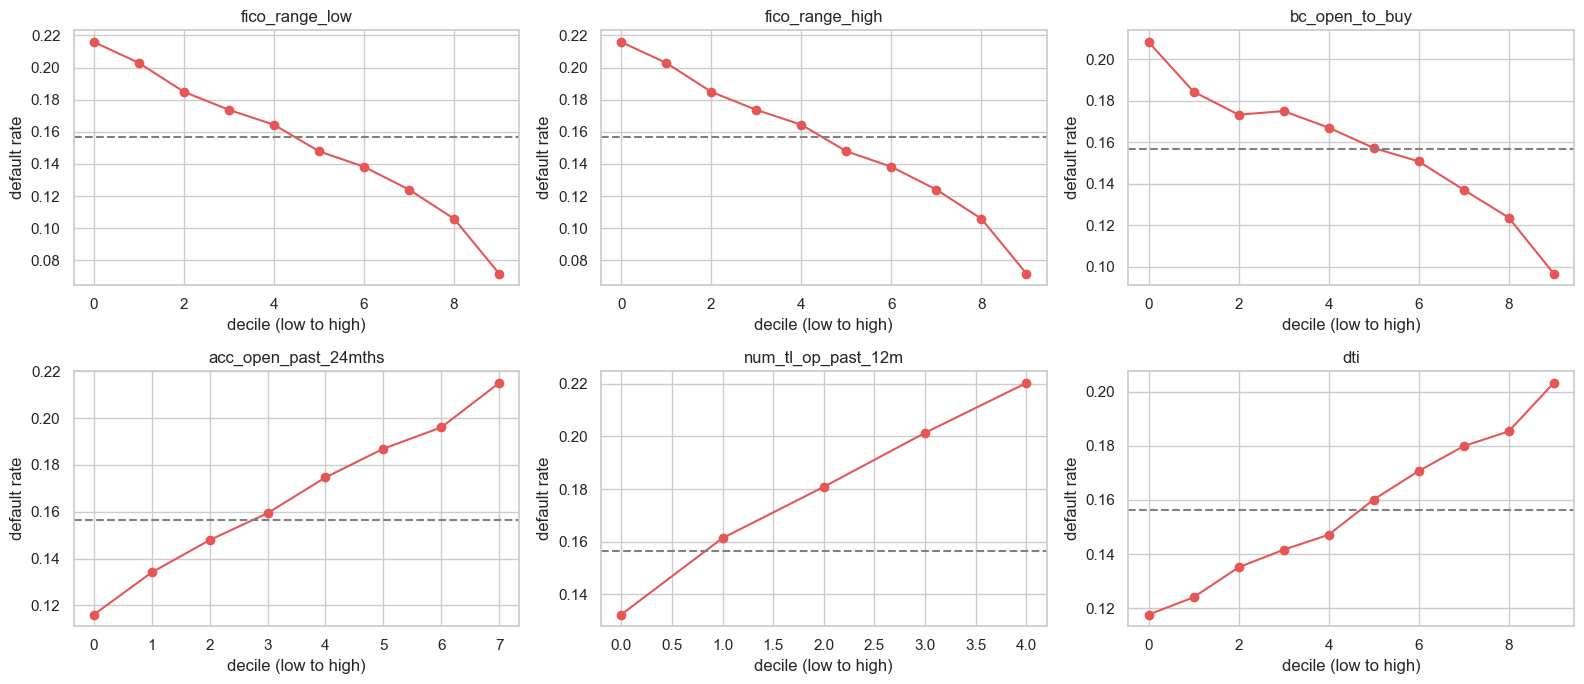

In [9]:
top6 = [c for c in num_stats.index if train[c].nunique() > 10][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, c in zip(axes.flat, top6):
    g = train.groupby(pd.qcut(train[c], 10, duplicates='drop'), observed=True)[TARGET].mean()
    ax.plot(range(len(g)), g.values, marker='o', color='#E45756')
    ax.axhline(train[TARGET].mean(), ls='--', color='grey')
    ax.set(title=c, xlabel='decile (low to high)', ylabel='default rate')
plt.tight_layout()
plt.show()

**Observation:** Default rates generally decrease as `fico_range_high`, `fico_range_low`, and `bc_open_to_buy` increase. In contrast, default rates increase with higher `acc_open_past_24mths`, `num_tl_op_past_12m`, and `dti`. These trends support the univariate AUC findings, showing that lower credit scores and available credit, and higher debt ratios and recent credit activity, are associated with higher default rates.


## 5. Highly correlated features

In [10]:
corr = train[num_cols].corr()
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs = pairs[pairs.abs() >= 0.9].sort_values(key=abs, ascending=False)
display(pairs.rename('correlation').reset_index().rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'}))

,feature_1,feature_2,correlation
0,fico_range_low,fico_range_high,1.000
1,open_acc,num_sats,0.999
2,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.998
3,tot_cur_bal,tot_hi_cred_lim,0.984
4,mo_sin_old_rev_tl_op,credit_hist_years,0.924
5,pub_rec_bankruptcies,mths_since_last_record_missing,-0.910


## 6. Tree-model check: permutation importance on the validation period

In [11]:
features = [c for c in df.columns if c not in (TARGET, 'issue_d', 'earliest_cr_line')]

model = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, categorical_features='from_dtype', random_state=42)
model.fit(train[features], train[TARGET])
print(f'Validation ROC-AUC: {roc_auc_score(valid[TARGET], model.predict_proba(valid[features])[:, 1]):.3f}')

Validation ROC-AUC: 0.711


,auc_drop,std,univariate_auc,cramers_v
term,0.067,0.001,NaN,0.148
annual_inc,0.022,0.000,0.445,NaN
loan_amnt,0.021,0.001,0.541,NaN
fico_range_low,0.018,0.002,0.409,NaN
dti,0.006,0.000,0.558,NaN
acc_open_past_24mths,0.006,0.000,0.565,NaN
addr_state,0.006,0.001,NaN,0.041
purpose,0.005,0.001,NaN,0.068
inq_last_6mths,0.003,0.000,0.549,NaN
mths_since_recent_bc,0.002,0.000,0.455,NaN


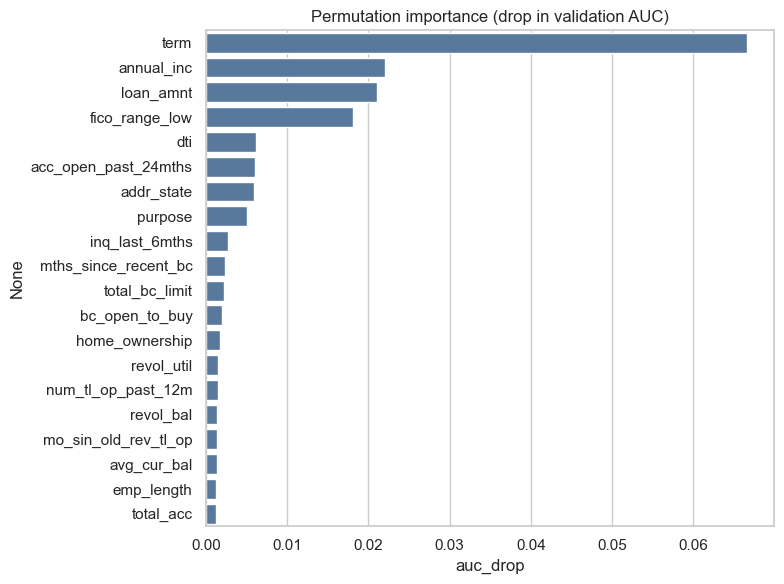

In [12]:
v = valid.sample(50_000, random_state=42)
perm = permutation_importance(model, v[features], v[TARGET], scoring='roc_auc', n_repeats=3, random_state=42, n_jobs=-1)

imp = pd.DataFrame({'auc_drop': perm.importances_mean, 'std': perm.importances_std}, index=features).sort_values('auc_drop', ascending=False)
imp['univariate_auc'] = num_stats['auc']
imp['cramers_v'] = cat_stats['cramers_v']
display(imp.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(x=imp.head(20)['auc_drop'], y=imp.head(20).index, color='#4C78A8')
plt.title('Permutation importance (drop in validation AUC)')
plt.tight_layout()
plt.show()

## 7. Decisions

**What the results show**
- No sign of leakage: no post-origination columns, and no single feature has AUC above 0.60.
- Strongest drivers (permutation importance, 2014 loans): `term` (AUC drop 0.067), then `annual_inc`, `loan_amnt`, `fico_range_low` (0.018 to 0.022), then `dti`, `acc_open_past_24mths`, `addr_state`, `purpose` (about 0.005). Everything else is 0.003 or less.
- 60-month loans default at 25.2% vs 12.6% for 36-month loans (train). Every single numeric feature is weak on its own (best AUC 0.59, FICO).
- With 230k rows every p-value is about 0, so features are ranked by effect size (AUC, Cramér's V), not p-values.
- About 30% of train loans (issued before mid-2012) have all newer credit-bureau fields missing; for 2013 and 2014 it is about 0%. The "default if missing" gaps in Section 2 are mostly an era effect, not a signal.
- Default rate shifts over time: 15.65% in train vs 18.45% in validation.

**Decisions**
1. **Split and metric:** train on loans issued up to 2013, validate on 2014. Use ROC-AUC and PR-AUC (17% default rate). Baseline to beat: 0.711 ROC-AUC (untuned gradient boosting).
2. **Drop duplicates:** `fico_range_high` (equals low + 4 in 99.99% of rows), `num_sats`, `num_rev_tl_bal_gt_0`, `tot_cur_bal` (correlation 0.98 to 1.00 with a kept column). Drop `earliest_cr_line` and `issue_d` as raw dates; keep `credit_hist_years`.
3. **Create:** `loan_to_income = loan_amnt / annual_inc`. Check on train gave AUC 0.593, above `loan_amnt` (0.541) and `annual_inc` (0.555) alone.
4. **Missing values:** do not treat missingness as a feature signal. Train two versions, all years vs only loans issued from 2013, and pick by validation AUC. Gradient boosting (HistGradientBoosting, XGBoost, LightGBM) takes NaN directly, so no imputation and the `_missing` flags can go. For sklearn RandomForest, fill with a sentinel such as -1 and keep the flags.
5. **No scaling, log transform or outlier capping:** tree splits are not affected by them.
6. **Categoricals:** use native categorical support or ordinal encoding for `purpose` (14) and `addr_state` (50); no one-hot. Keep `term` as numeric 36/60.
7. **Weak features:** `emp_length` (V 0.010) and `zip_code` (V 0.022) are drop candidates. Confirm by removing them and checking validation AUC. Keep `addr_state` for now (V 0.041, importance 0.006) and recheck its stability over time.
8. **Caveats:** `term` importance may be inflated because 2014 60-month loans default at 31% and may be right-censored; report validation AUC separately for 36 and 60 months. Permutation importance splits credit between correlated features, so re-run it after step 2.